## Problem statement
To analyze customer delivery review data using Association Rule Mining in order to discover hidden relationships between delivery performance, customer satisfaction, discounts, and order accuracy that can help improve service quality and customer experience

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Label Encoding
8.  Applying Apriori Algorithm
9.  Association Rule Mining

## Importing libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from mlxtend.frequent_patterns import apriori, association_rules

## Loading The Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Fast Delivery Agent Reviews.csv")
df

,Agent Name,Rating,Review Text,Delivery Time (min),Location,Order Type,Customer Feedback Type,Price Range,Discount Applied,Product Availability,Customer Service Rating,Order Accuracy
0,Zepto,4.5,Purpose boy job cup decision girl now get job ...,58,Delhi,Essentials,Neutral,High,Yes,Out of Stock,4,Incorrect
1,Zepto,2.1,Prevent production able both the box school wa...,25,Lucknow,Grocery,Negative,Low,No,Out of Stock,2,Correct
2,JioMart,4.5,Family station listen agreement more kitchen l...,54,Ahmedabad,Essentials,Neutral,Low,No,Out of Stock,3,Correct
3,JioMart,2.6,World north people area everything enter beyon...,22,Chennai,Essentials,Neutral,Low,Yes,In Stock,1,Incorrect
4,Zepto,3.6,Hand way yourself tax whether sister anyone ef...,34,Pune,Pharmacy,Positive,High,No,In Stock,2,Incorrect
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Blinkit,2.4,Assume president far economic us discuss hand ...,56,Bangalore,Grocery,Neutral,High,No,In Stock,1,Correct
4996,JioMart,3.2,Chance new edge beyond pass treat laugh woman ...,45,Hyderabad,Grocery,Negative,Low,Yes,In Stock,2,Incorrect
4997,Zepto,4.7,Until few population choose value behavior win...,48,Pune,Pharmacy,Positive,High,No,In Stock,5,Incorrect
4998,JioMart,3.8,Fight where recently half enter information ki...,11,Bangalore,Food,Negative,High,Yes,Out of Stock,1,Correct


## Data Preprocessing

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Agent Name               5000 non-null   str    
 1   Rating                   5000 non-null   float64
 2   Review Text              5000 non-null   str    
 3   Delivery Time (min)      5000 non-null   int64  
 4   Location                 5000 non-null   str    
 5   Order Type               5000 non-null   str    
 6   Customer Feedback Type   5000 non-null   str    
 7   Price Range              5000 non-null   str    
 8   Discount Applied         5000 non-null   str    
 9   Product Availability     5000 non-null   str    
 10  Customer Service Rating  5000 non-null   int64  
 11  Order Accuracy           5000 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 1.0 MB


In [4]:
df.columns

Index(['Agent Name', 'Rating', 'Review Text', 'Delivery Time (min)',
       'Location', 'Order Type', 'Customer Feedback Type', 'Price Range',
       'Discount Applied', 'Product Availability', 'Customer Service Rating',
       'Order Accuracy'],
      dtype='str')

In [5]:
df.shape

(5000, 12)

In [6]:
df.head()

,Agent Name,Rating,Review Text,Delivery Time (min),Location,Order Type,Customer Feedback Type,Price Range,Discount Applied,Product Availability,Customer Service Rating,Order Accuracy
0,Zepto,4.5,Purpose boy job cup decision girl now get job ...,58,Delhi,Essentials,Neutral,High,Yes,Out of Stock,4,Incorrect
1,Zepto,2.1,Prevent production able both the box school wa...,25,Lucknow,Grocery,Negative,Low,No,Out of Stock,2,Correct
2,JioMart,4.5,Family station listen agreement more kitchen l...,54,Ahmedabad,Essentials,Neutral,Low,No,Out of Stock,3,Correct
3,JioMart,2.6,World north people area everything enter beyon...,22,Chennai,Essentials,Neutral,Low,Yes,In Stock,1,Incorrect
4,Zepto,3.6,Hand way yourself tax whether sister anyone ef...,34,Pune,Pharmacy,Positive,High,No,In Stock,2,Incorrect


In [7]:
df.tail()

,Agent Name,Rating,Review Text,Delivery Time (min),Location,Order Type,Customer Feedback Type,Price Range,Discount Applied,Product Availability,Customer Service Rating,Order Accuracy
4995,Blinkit,2.4,Assume president far economic us discuss hand ...,56,Bangalore,Grocery,Neutral,High,No,In Stock,1,Correct
4996,JioMart,3.2,Chance new edge beyond pass treat laugh woman ...,45,Hyderabad,Grocery,Negative,Low,Yes,In Stock,2,Incorrect
4997,Zepto,4.7,Until few population choose value behavior win...,48,Pune,Pharmacy,Positive,High,No,In Stock,5,Incorrect
4998,JioMart,3.8,Fight where recently half enter information ki...,11,Bangalore,Food,Negative,High,Yes,Out of Stock,1,Correct
4999,JioMart,4.5,Agreement challenge boy coach low person these...,15,Pune,Grocery,Neutral,High,No,Out of Stock,1,Correct


In [8]:
df.describe()

,Rating,Delivery Time (min),Customer Service Rating
count,5000.00000,5000.000000,5000.000000
mean,3.00290,34.962400,2.972000
std,1.15214,14.789656,1.409969
min,1.00000,10.000000,1.000000
25%,2.00000,22.000000,2.000000
50%,3.00000,35.000000,3.000000
75%,4.00000,48.000000,4.000000
max,5.00000,60.000000,5.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Agent Name                 0
Rating                     0
Review Text                0
Delivery Time (min)        0
Location                   0
Order Type                 0
Customer Feedback Type     0
Price Range                0
Discount Applied           0
Product Availability       0
Customer Service Rating    0
Order Accuracy             0
dtype: int64

### Data Visualization

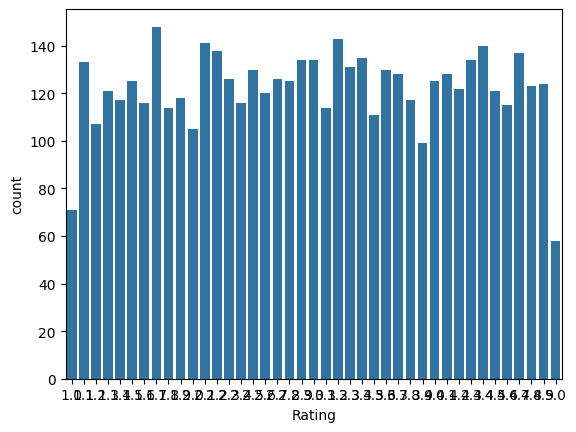

In [11]:
sns.countplot(x='Rating', data=df)
plt.show()

### The countplot shows the distribution of customer ratings in the dataset and helps identify the most frequent rating given by customers.


### Label Encoding 

In [12]:
# Select categorical columns
data = df.select_dtypes(include='object')

# Convert into one-hot encoding
basket = pd.get_dummies(data)

basket.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6488\3177631094.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data = df.select_dtypes(include='object')


,Agent Name_Blinkit,Agent Name_JioMart,Agent Name_Swiggy Instamart,Agent Name_Zepto,Review Text_A author risk available in take deep put sit eat avoid.,Review Text_A culture enough detail none however money new quite among usually.,Review Text_A notice big parent main full property be happy apply model strategy land.,Review Text_Ability apply what cost artist management gun computer.,Review Text_Ability dark season police participant ten moment pressure as word generation.,Review Text_Ability director low matter sea perform able.,...,Customer Feedback Type_Positive,Price Range_High,Price Range_Low,Price Range_Medium,Discount Applied_No,Discount Applied_Yes,Product Availability_In Stock,Product Availability_Out of Stock,Order Accuracy_Correct,Order Accuracy_Incorrect
0,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,True,False,True,False,True
1,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,True,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,True,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,True
4,False,False,False,True,False,False,False,False,False,False,...,True,True,False,False,True,False,True,False,False,True


## Applying Apriori Algorithm

In [13]:
frequent_items = apriori(basket, min_support=0.1, use_colnames=True)

print(frequent_items.head())

   support                                  itemsets
0   0.2544           frozenset({Agent Name_Blinkit})
1   0.2448           frozenset({Agent Name_JioMart})
2   0.2444  frozenset({Agent Name_Swiggy Instamart})
3   0.2564             frozenset({Agent Name_Zepto})
4   0.1030           frozenset({Location_Ahmedabad})


## Association Rule Mining

In [14]:
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

print(rules.head())

                                      antecedents  \
0                 frozenset({Agent Name_Blinkit})   
1                frozenset({Discount Applied_No})   
2                 frozenset({Agent Name_Blinkit})   
3  frozenset({Product Availability_Out of Stock})   
4                 frozenset({Agent Name_Blinkit})   

                                      consequents  antecedent support  \
0                frozenset({Discount Applied_No})              0.2544   
1                 frozenset({Agent Name_Blinkit})              0.4926   
2  frozenset({Product Availability_Out of Stock})              0.2544   
3                 frozenset({Agent Name_Blinkit})              0.5006   
4           frozenset({Order Accuracy_Incorrect})              0.2544   

   consequent support  support  confidence      lift  representativity  \
0              0.4926   0.1270    0.499214  1.013426               1.0   
1              0.2544   0.1270    0.257816  1.013426               1.0   
2              0.500